# Install Required Libraries

In [ ]:
!pip install torch torchvision timm opencv-python matplotlib pillow

# Import Libraries

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms

from google.colab import files

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# Upload Trained Model

In [ ]:
uploaded = files.upload()

Saving image_detector_v1 (1).pth to image_detector_v1 (1).pth


# Store Model Path

In [ ]:
MODEL_PATH = list(uploaded.keys())[0]

print("Model File :", MODEL_PATH)

Model File : image_detector_v1 (1).pth


# Create EfficientNet Architecture

In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("Model Loaded Successfully")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s]


Model Loaded Successfully


# Load Trained Weights

In [ ]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


# Define Image Transform

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# Upload Test Image

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
print("Selected image:", image_path)

Saving 912 (6).jpg to 912 (6) (3).jpg
Selected image: 912 (6) (3).jpg


In [ ]:
from PIL import Image

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(1,1), dpi=32)

plt.imshow(image)

plt.title(f"{image.size[0]}×{image.size[1]}")

plt.axis("off")

plt.show()

In [ ]:
input_tensor = transform(image)

input_tensor = input_tensor.unsqueeze(0)

input_tensor = input_tensor.to(device)

In [ ]:
with torch.no_grad():

    output = model(input_tensor)

    probability = torch.softmax(output, dim=1)

    confidence, prediction = torch.max(probability,1)

In [ ]:
classes = ["FAKE","REAL"]

print("Prediction :", classes[prediction.item()])
print("Confidence :", round(confidence.item()*100,2),"%")

Prediction : FAKE
Confidence : 99.93 %


# FFT + PRNU Analysis

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

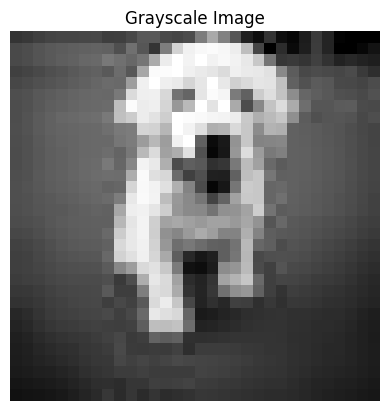

In [ ]:
gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
fft = np.fft.fft2(gray)
fft_shift = np.fft.fftshift(fft)

magnitude = np.log(np.abs(fft_shift) + 1)

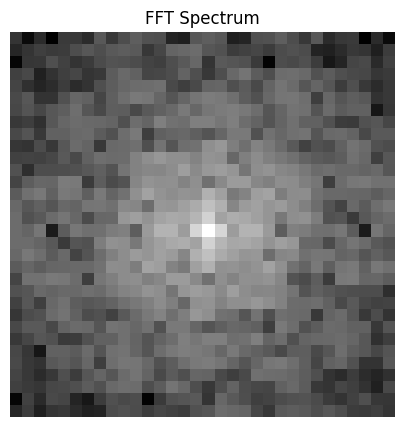

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(magnitude,cmap="gray")

plt.title("FFT Spectrum")

plt.axis("off")

plt.show()

In [ ]:
fft_mean = np.mean(magnitude)

fft_std = np.std(magnitude)

fft_energy = np.sum(magnitude**2)

hist,_ = np.histogram(
    magnitude,
    bins=256,
    density=True
)

fft_entropy = entropy(hist+1e-8)

h,w = magnitude.shape

center = magnitude[
    h//4:3*h//4,
    w//4:3*w//4
]

hf_ratio = np.sum(magnitude)/np.sum(center)

print("FFT Mean :",fft_mean)
print("FFT Std :",fft_std)
print("FFT Energy :",fft_energy)
print("FFT Entropy :",fft_entropy)
print("HF Ratio :",hf_ratio)

FFT Mean : 6.036135999868387
FFT Std : 1.1748418024660139
FFT Energy : 38722.755655402216
FFT Entropy : 4.6933528154630935
HF Ratio : 3.27399356496262


In [ ]:
blur = cv2.GaussianBlur(gray,(5,5),0)

noise = gray.astype(np.float32)-blur.astype(np.float32)

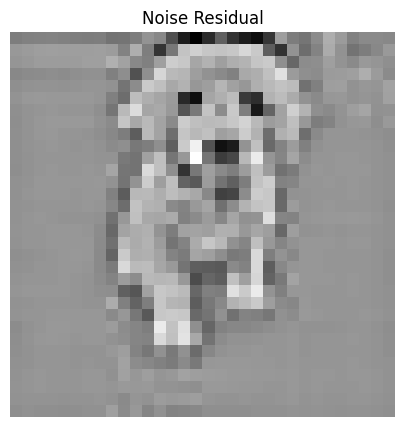

In [ ]:
plt.figure(figsize=(5,5))

plt.imshow(noise,cmap="gray")

plt.title("Noise Residual")

plt.axis("off")

plt.show()

In [ ]:
prnu_mean = np.mean(noise)

prnu_std = np.std(noise)

prnu_energy = np.sum(noise**2)

prnu_variance = np.var(noise)

corr = np.corrcoef(
    gray.flatten(),
    noise.flatten()
)[0,1]

if np.isnan(corr):
    corr=0

print("PRNU Mean :",prnu_mean)
print("PRNU Std :",prnu_std)
print("PRNU Energy :",prnu_energy)
print("PRNU Variance :",prnu_variance)
print("Correlation :",corr)

PRNU Mean : -0.5966797
PRNU Std : 19.056362
PRNU Energy : 372225.0
PRNU Variance : 363.14496
Correlation : 0.5416520118534769


In [ ]:
cnn_prediction = classes[prediction.item()]

cnn_confidence = confidence.item()

print(cnn_prediction)
print(cnn_confidence)

FAKE
0.9993261098861694


In [ ]:
fft_vote = "REAL"

if fft_entropy > 5.0:
    fft_vote = "FAKE"

print("FFT Vote :",fft_vote)

FFT Vote : REAL


In [ ]:
prnu_vote = "REAL"

if prnu_std < 20:
    prnu_vote = "FAKE"

print("PRNU Vote :",prnu_vote)

PRNU Vote : FAKE


In [ ]:
votes = [
    cnn_prediction,
    fft_vote,
    prnu_vote
]

fake_votes = votes.count("FAKE")

real_votes = votes.count("REAL")

if fake_votes>real_votes:
    final_prediction="FAKE"
else:
    final_prediction="REAL"

print(final_prediction)

FAKE


In [ ]:
agreement = votes.count(cnn_prediction)

if agreement==3:

    final_confidence=min(
        cnn_confidence+0.05,
        1.0
    )

elif agreement==2:

    final_confidence=cnn_confidence

else:

    final_confidence=max(
        cnn_confidence-0.15,
        0
    )

print(final_confidence)

0.9993261098861694


In [ ]:
print("="*50)

print("IMAGE ANALYSIS REPORT")

print("="*50)

IMAGE ANALYSIS REPORT


In [ ]:
print("Prediction :",final_prediction)

print("Confidence :",round(final_confidence*100,2),"%")

Prediction : FAKE
Confidence : 99.93 %


In [ ]:
print("\nCNN")

print("----------------")

print("Prediction :",cnn_prediction)

print("Confidence :",round(cnn_confidence*100,2),"%")


CNN
----------------
Prediction : FAKE
Confidence : 99.93 %


In [ ]:
print("\nFFT")

print("----------------")

if fft_vote=="FAKE":

    print("High-frequency artifacts detected.")

else:

    print("Normal frequency distribution.")


FFT
----------------
Normal frequency distribution.


In [ ]:
print("\nPRNU")

print("----------------")

if prnu_vote=="FAKE":

    print("Weak camera fingerprint detected.")

else:

    print("Camera fingerprint appears consistent.")


PRNU
----------------
Weak camera fingerprint detected.


In [ ]:
print("\nReason")

print("----------------")

if final_prediction=="FAKE":

    print("CNN prediction is supported by forensic evidence from FFT and PRNU analysis.")

else:

    print("CNN prediction is supported by consistent frequency and camera sensor characteristics.")


Reason
----------------
CNN prediction is supported by forensic evidence from FFT and PRNU analysis.
